# Video Face Manipulation Detection Through Ensemble of CNNs
Image and Sound Processing Lab - Politecnico di Milano ([GITHUB](https://github.com/polimi-ispl/icpr2020dfdc))


##Clone the github repository containing the project and install necessary libraries.

In [ ]:
from IPython.display import clear_output


!git clone https://github.com/polimi-ispl/icpr2020dfdc
!pip install efficientnet-pytorch
!pip install -U git+https://github.com/albu/albumentations > /dev/null
!pip -q install -U pydrive2
%cd icpr2020dfdc/notebook

import sys
sys.path.append('..')

clear_output()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


This step is necessary because the opencv version already installed is not the one we need. \
Type "yes" to continue.

In [ ]:

!pip install -U "numpy==1.23.5" "opencv-python-headless==4.5.5.62"



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 75.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


## Import necessary libraries and download the dataset.

In [ ]:
!pip -q install -U pydrive2

In [ ]:
import numpy as np
import torch
from torch.utils.model_zoo import load_url
import matplotlib.pyplot as plt
from scipy.special import expit
import cv2
from scipy import stats
import os

import re
import pandas as pd
from os import listdir
from os.path import isfile, join

from datetime import datetime

import sys
sys.path.append('..')

from blazeface import FaceExtractor, BlazeFace, VideoReader
from architectures import fornet,weights
from isplutils import utils
from IPython.display import HTML, display
from IPython.display import clear_output

def progress(value, max=100):
  return HTML("""<progress value='{value}' max='{max}', style='width: 100%'> {value} """.format(value=value, max=max))

from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

%cd /content

downloaded = drive.CreateFile({'id': '1h6OudIxHlgAKrW8mvjbUQJwh_QUBRG1T'})   # replace the id with id of file you want to access
downloaded.GetContentFile('dataset_esercitazione_deepfake.zip')        # replace the file name with your file
!unzip dataset_esercitazione_deepfake
clear_output()
print('Done! Press the Refresh button if files are not visible.')

Done! Press the Refresh button if files are not visible.


## Choose desired network architecture and training database.

In [ ]:
"""
Choose an architecture between
- EfficientNetB4
- EfficientNetB4ST
- EfficientNetAutoAttB4
- EfficientNetAutoAttB4ST
- Xception
"""
net_model = 'EfficientNetAutoAttB4ST'

"""
Choose a training dataset between
- DFDC
- FFPP
"""
train_db ='DFDC'

## Select parameters.

In [ ]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
face_policy = 'scale'
face_size = 224
frames_per_video = 32

## Load the related pre-trained model

In [ ]:
model_url = weights.weight_url['{:s}_{:s}'.format(net_model,train_db)]
net = getattr(fornet,net_model)().eval().to(device)
net.load_state_dict(load_url(model_url,map_location=device,check_hash=True))

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b4-6ed6700e.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b4-6ed6700e.pth
100%|██████████| 74.4M/74.4M [00:00<00:00, 153MB/s]


Loaded pretrained weights for efficientnet-b4


Downloading: "https://f002.backblazeb2.com/file/icpr2020/EfficientNetAutoAttB4ST_DFDC_bestval-4df0ef7d2f380a5955affa78c35d0942ac1cd65229510353b252737775515a33.pth" to /root/.cache/torch/hub/checkpoints/EfficientNetAutoAttB4ST_DFDC_bestval-4df0ef7d2f380a5955affa78c35d0942ac1cd65229510353b252737775515a33.pth
100%|██████████| 33.9M/33.9M [00:00<00:00, 47.4MB/s]


<All keys matched successfully>

## Initialization of needed objects

In [ ]:
transf = utils.get_transformer(face_policy, face_size, net.get_normalizer(), train=False)
facedet = BlazeFace().to(device)
facedet.load_weights("/content/icpr2020dfdc/blazeface/blazeface.pth")
facedet.load_anchors("/content/icpr2020dfdc/blazeface/anchors.npy")
videoreader = VideoReader(verbose=False)
video_read_fn = lambda x: videoreader.read_frames(x, num_frames=frames_per_video)
face_extractor = FaceExtractor(video_read_fn=video_read_fn,facedet=facedet)

/content/icpr2020dfdc/notebook/../isplutils/utils.py:155: UserWarning: Argument(s) 'value, always_apply' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=patch_size, min_width=patch_size,
/content/icpr2020dfdc/notebook/../isplutils/utils.py:157: UserWarning: Argument(s) 'always_apply' are not valid for transform Resize
  A.Resize(height=patch_size,width=patch_size,always_apply=True),


## Load videos to be analyzed.

In [ ]:
vid_real_faces = face_extractor.process_video('/content/Live/001.mp4')
vid_fake_faces = face_extractor.process_video('/content/Deepfakes/001_870.mp4')


In [ ]:
print(len(vid_fake_faces))

32


## Visualize the face extracted from one frame of the videos.

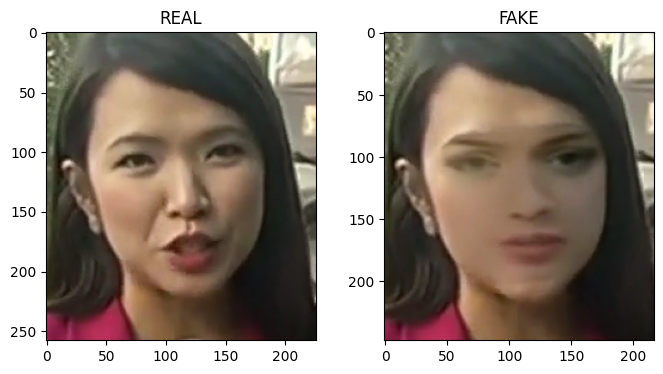

In [ ]:
im_real_face = vid_real_faces[10]['faces'][0]
im_fake_face = vid_fake_faces[10]['faces'][0]

fig,ax = plt.subplots(1,2,figsize=(8,4))

ax[0].imshow(im_real_face)
ax[0].set_title('REAL')

ax[1].imshow(im_fake_face)
ax[1].set_title('FAKE');

## Collect faces and make predictions.

In [ ]:
# For each frame, we consider the face with the highest confidence score found by BlazeFace (= frame['faces'][0])
faces_real_t = torch.stack( [ transf(image=frame['faces'][0])['image'] for frame in vid_real_faces if len(frame['faces'])] )
faces_fake_t = torch.stack( [ transf(image=frame['faces'][0])['image'] for frame in vid_fake_faces if len(frame['faces'])] )

with torch.no_grad():
    faces_real_pred = net(faces_real_t.to(device)).cpu().numpy().flatten()
    faces_fake_pred = net(faces_fake_t.to(device)).cpu().numpy().flatten()

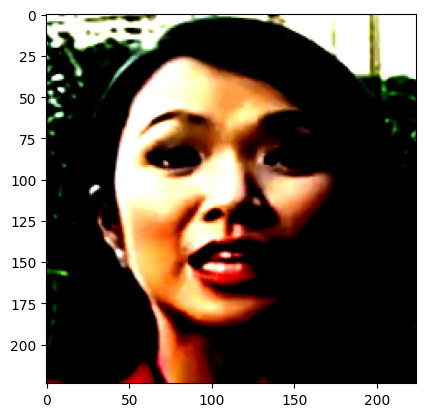

In [ ]:
plt.imshow(faces_real_t[0].permute(1,2,0))

## Plot the results for each frame of the video.
1 -->  FAKE \
0 -->  LIVE

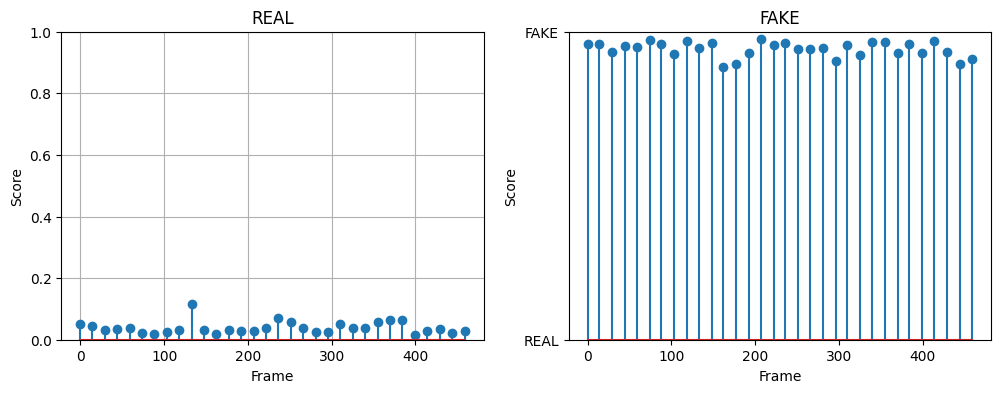

In [ ]:
fig,ax = plt.subplots(1,2,figsize=(12,4))

ax[0].stem([f['frame_idx'] for f in vid_real_faces if len(f['faces'])],expit(faces_real_pred))
ax[0].set_title('REAL')
ax[0].set_xlabel('Frame')
ax[0].set_ylabel('Score')
ax[0].set_ylim([0,1])
ax[0].grid(True)

ax[1].stem([f['frame_idx'] for f in vid_fake_faces if len(f['faces'])],expit(faces_fake_pred))
ax[1].set_title('FAKE')
ax[1].set_xlabel('Frame')
ax[1].set_ylabel('Score')
ax[1].set_ylim([0,1])
ax[1].set_yticks([0,1],['REAL','FAKE']);

## Compute the average score per video.

In [ ]:
"""
Print average scores.
An average score close to 0 predicts REAL. An average score close to 1 predicts FAKE.
"""
print('Average score for REAL video: {:.4f}'.format(expit(faces_real_pred.mean())))
print('Average score for FAKE face: {:.4f}'.format(expit(faces_fake_pred.mean())))

Average score for REAL video: 0.0352
Average score for FAKE face: 0.9479
